# Data Science Lab: Lab 1

Submit:

A read-only link to your colab notebook, executed and saved (so that we can run it, but don't necessarily have to, to see your results).

For any questions that require written explanation, please use Markdown - it is a lot easier for us to read than comments in the code.

**If you used any AI help, please describe how you used it and what you used.**

**Goals of this Lab:**
1.  Practice with Pandas, Numpy and Data Exploration.
2.  Download a more realistic data set and explore it!
3.  Training vs testing error
4.  (Optional) Review important results from probability, such as the CLT.

Group Members:
- Alfred Morales
- Arnau Arévalo
- Rowan Becker
- Siyoung Kim

In [ ]:
# Some useful libraries
import numpy as np
from numpy.random import default_rng

#Pandas for data structure and analysis tools
import pandas as pd

#seaborn and matplotlib for plotting
import seaborn as sns
import matplotlib.pyplot as plt

#for nice vector graphics
%matplotlib inline

#from IPython.display import set_matplotlib_formats
#set_matplotlib_formats('png', 'pdf')

np.random.seed(42) # Fixed seed for reproducibility
rng = default_rng(42)

# Problem 1

In class we explored the diabetes dataset using decision trees.

Part 1. load that data set again.

Part 2. Filter out any data points that missing data -- we did this just for data points that had missing BMI or Glucose values. How many data points did you end up filtering out?

Part 3: Figure out how to run logistic regression from ``sklearn``. Note that except for importing the right sklearn library, your code should adhere to our basic paradigm:
```
model = FamilyOfModels
model.fit(X,y)
model.predict(x)
```

Part 4: Report the accuracy of your model, by using the command ``model.predict`` just like we did for trees.

Part 5: Plot the decision boundary -- this should be a simple cut-and-paste from the code we used.

Bonus: do the same thing for XGBoost.

In [ ]:
# Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

# Replace 'path_to_your_file.csv' with the actual path to your CSV file
file_path = '/content/drive/MyDrive/ECE_460J/diabetes.csv'
diabetes_data = pd.read_csv(file_path) #reads the CSV file located at file_path,
                                       #loads the data into a Pandas DataFrame
                                       #and assigns it to the variable diabetes_data.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ECE_460J/diabetes.csv'

In [ ]:
filtered_data = diabetes_data[(diabetes_data['Glucose'] != 0) & (diabetes_data['BMI'] != 0)]
X = filtered_data[['Glucose', 'BMI']].values
y = filtered_data['Outcome'].values
print(f'Part 2 Answer: Filtered out {len(diabetes_data) - len(filtered_data)} data points.')
#or print(filtered_data.shape)


Part 2 Answer: Filtered out 16 data points.


In [ ]:

# import the necessary libraries
from sklearn import tree #import the tree module from the scikit-learn library
from sklearn.tree import DecisionTreeClassifier # used to create a decision tree classifier
from sklearn.metrics import accuracy_score # used to calculate the accuracy of a classification model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)


LogisticRegression()

In [ ]:
predicted_y = model.predict(X)
print(f'Part 4 Answer: {accuracy_score(y, predicted_y)}')

Part 4 Answer: 0.7646276595744681


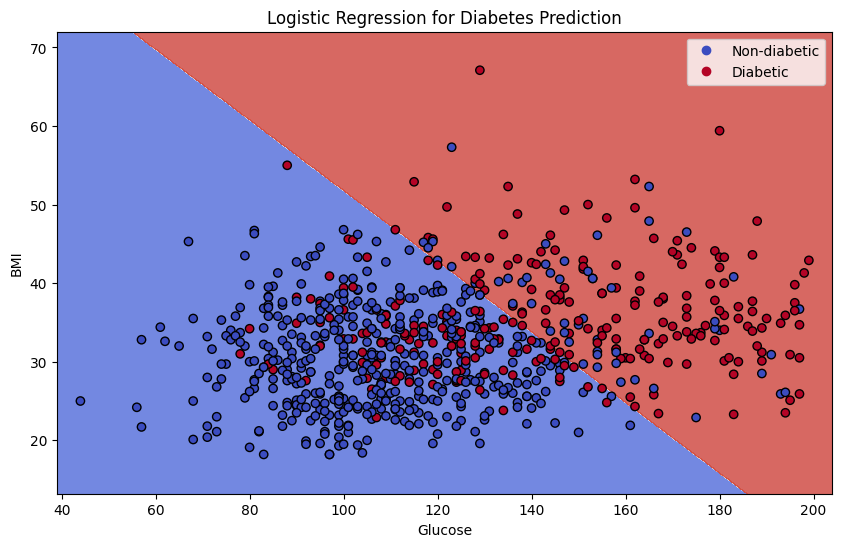

In [ ]:
# Define the grid range based on your data
x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

# Create a meshgrid
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
# Predict the outcome on the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Plot the training points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Logistic Regression for Diabetes Prediction')
plt.legend(handles=scatter.legend_elements()[0], labels=['Non-diabetic', 'Diabetic'])
plt.show()


# Problem 2

Hospitals are penalized for avoidable 30-day readmissions. We're going to do some preliminary exploration of a data set that explores this topic.

The UCI Diabetes data set assembles a data set with over 100,000 data points, collecting data from 130-US hospitals, compiled over 10 years (1999–2008).

You can load this with the following commands (you may need to ``!pip install ucimlrepo``)
```
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=296)
X_uci = ds.data.features   # pandas DataFrame of features
y_uci  = ds.data.targets    # target(s), incl. readmitted
```

Part 1. How many data points and how many features does the above dataset have? How many of the features are ``numerical``, and how many are ``categorical``?

Part 2. Run the following pandas commands
```
y_uci.value_counts()
X_uci.head()
X_uci.info()
X_uci.describe()
X_uci.isna().sum()
X_uci.isna().mean()
```
and very briefly, say what each command is doing.

Part 3: How many missing values are there per column?  How many rows are complete, i.e., how many rows would survive if we removed each row that had at least one missing value?

Part 4: Plot histograms for each of the following columns:
* "time_in_hospital"
* "num_lab_procedures"
* "num_procedures"
* "num_medications"
* "number_outpatient"
* "number_emergency"
* "number_inpatient"
* "number_diagnoses"

There are many ways to plot a histogram. One way is using ``seaborn`` via the command
``sns.histplot(X_uci['age'].dropna(), bins=30, kde=False)``.

Part 5. (Optional) We're not going to do much more with this dataset, but it's a far richer and more complex dataset than our first Diabetes dataset. Feel free to try running decision trees, logistic regression, or anything else. If you do, I recommend you compare concepts such as **accuracy**, **balanced accuracy**, and **auc_roc** (we will be discussing these a little later).


In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

ds = fetch_ucirepo(id=296)
X_uci = ds.data.features   # pandas DataFrame of features
y_uci  = ds.data.targets    # target(s), incl. readmitted

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [ ]:
data_points = X_uci.shape[0]
features = X_uci.shape[1]

print(f"Number of data points: {data_points:,}")
print(f"Number of features: {features}")

num_features = X_uci.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_uci.select_dtypes(include=['object']).columns

print(f"Numerical features: {len(num_features)}")
print(f"Categorical featues: {len(cat_features)}")

Number of data points: 101,766
Number of features: 47
Numerical features: 11
Categorical featues: 36


In [ ]:
y_uci.value_counts()
X_uci.head()
X_uci.info()
X_uci.describe()
X_uci.isna().sum()
X_uci.isna().mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

,0
race,0.022336
gender,0.000000
age,0.000000
weight,0.968585
admission_type_id,0.000000
discharge_disposition_id,0.000000
admission_source_id,0.000000
time_in_hospital,0.000000
payer_code,0.395574
medical_specialty,0.490822


y_uci.value_counts() = shows how many patients were readmitted before or after 30 days vs not readmitted

X_uci.head() = displays the first 5 rows of the dataframe

X_uci.info() = displays a summary of the dataframe

X_uci.describe() = shows numerical statistics for all the numerical columns

X_uci.isna().sum() = counts the number of missing values in each column

X_uci.isna().mean() = calculates the percentage of missing values in each column

In [ ]:
missing_per_column = X_uci.isna().sum()
print("Missing values per column:")
print(missing_per_column[missing_per_column > 0])

complete_rows = X_uci.dropna().shape[0]
print(f"\nNumber of complete rows (no missing values): {complete_rows:,}")

Missing values per column:
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64

Number of complete rows (no missing values): 0


<Axes: xlabel='time_in_hospital', ylabel='Count'>

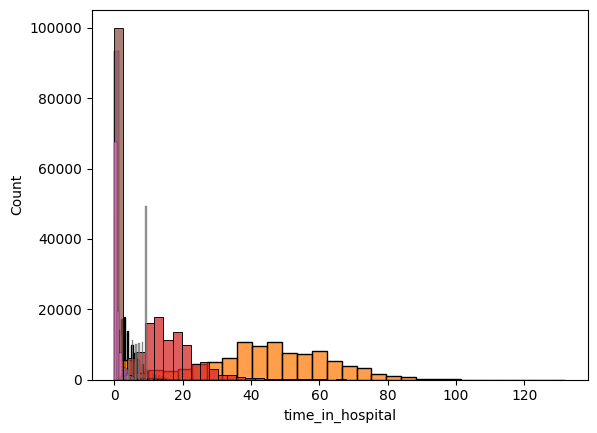

In [ ]:
sns.histplot(X_uci['time_in_hospital'].dropna(), bins=30, kde=False)
sns.histplot(X_uci['num_lab_procedures'].dropna(), bins=30, kde=False)
sns.histplot(X_uci['num_procedures'].dropna(), bins=30, kde=False)
sns.histplot(X_uci['num_medications'].dropna(), bins=30, kde=False)
sns.histplot(X_uci['number_outpatient'].dropna(), bins=30, kde=False)
sns.histplot(X_uci['number_emergency'].dropna(), bins=30, kde=False)
sns.histplot(X_uci['number_inpatient'].dropna(), bins=30, kde=False)
sns.histplot(X_uci['number_diagnoses'].dropna(), bins=30, kde=False)



# Problem 3

The goal of this exercise is for you to get more experience with Pandas, and to get a chance to explore a cool data set.  Download the file Names.zip from Canvas.  This contains the frequency of all names that appeared more than 5 times on a social security application from 1880 through 2015.

Part 1. Write a program that on input $k$ and XXXX, returns the top $k$ names from year XXXX.

Part 2. Write a program that on input Name returns the frequency for men and women of the name Name.

Part 3. It could be that names are more diverse now than they were in 1880, so that a name may be relatively the most popular, though its frequency may have been decreasing over the years.  Modify the above to return the relative frequency. (Note from lab: relative to that year only, i.e., sum the total for that year)

Part 4. Find all the names that used to be more popular for one gender, but then became more popular for another gender.

•(Optional) Find something cool about this data set.

In [ ]:
# Remember to run the first two code sections to mount the drive
names_folder_path = '/content/drive/MyDrive/ECE_460J/Names'
import os

# Returns a DataFrame of the data for the specified year
def get_year_data(year):
  column_names = ['Name', 'Gender', 'Frequency']
  df = pd.read_csv(os.path.join(names_folder_path, f'yob{year}.txt'), header=None, names=column_names)
  df.sort_values(by='Frequency', ascending=False)
  return df

# Returns top k names for a given year
def get_top_k_names(k, year):
  year_df = get_year_data(year)
  return year_df['Name'].head(k)

print(f'Part 1 Answer: \n{get_top_k_names(5, 2015)}\n')

# Returns the frequency of name for the given year for both men and women
def get_name_frequencies(year, name):
  year_df = get_year_data(year)
  name_frequencies = year_df[year_df['Name'] == name].copy()
  return name_frequencies

print(f'Part 2: \n{get_name_frequencies(2015, 'Rowan')}\n')

def get_relative_name_frequencies(year, name):
  year_df = get_year_data(year)
  frequency_total = year_df['Frequency'].sum()
  name_frequencies = year_df[year_df['Name'] == name].copy()

  if len(name_frequencies) > 0:
    name_frequencies['Frequency'] = name_frequencies['Frequency'].astype(float)
    name_frequencies.loc[:, 'Frequency'] = name_frequencies['Frequency'] / frequency_total

  return name_frequencies

print(f'Part 3: \n{get_relative_name_frequencies(2015, 'Rowan')}\n')

def find_swapped_names(df):
  # Delete ties
  df = df[~df.duplicated(subset=['Name', 'Year', 'Frequency'], keep=False)]

  sorted_df = df.sort_values(by='Frequency', ascending=False)
  popular_gender_df = sorted_df.drop_duplicates(subset=['Name', 'Year'], keep='first')
  gender_counts = popular_gender_df.groupby('Name')['Gender'].nunique()
  switched_names = gender_counts[gender_counts > 1]

  return switched_names.index.tolist()

# Assuming a tie does not count as a change, and going from a tie to one being more popular doesn't either.
def find_name_popularity_gender_swap(threshold=0):
  all_year_dataframes = []

  for year in range(1880, 2016):
    df = get_year_data(year)
    df['Year'] = year
    all_year_dataframes.append(df)

  # ['Name', 'Gender', 'Frequency', 'Year']
  full_df = pd.concat(all_year_dataframes, ignore_index=True)


  if threshold > 0:
    # Get rid of low frequency names, so at least one of the genders for that year has to have at least the threshold
    group_maxes = full_df.groupby(['Name', 'Year'])['Frequency'].transform('max')
    filtered_df = full_df[group_maxes >= threshold]

    print(f'Initial unique names: {full_df['Name'].nunique()}')
    print(f'Unique names after filtering frequencies under {threshold}: {filtered_df['Name'].nunique()}')
  else:
    filtered_df = pd.DataFrame()

  swapped_names = find_swapped_names(full_df)
  filtered_swaps = find_swapped_names(filtered_df)

  return swapped_names, filtered_swaps

print('Part 4:')
swapped_names, filtered_name_swaps = find_name_popularity_gender_swap(10)
print(f'Swapped names: {swapped_names}')
print(f'Total swapped names: {len(swapped_names)}\n')

print(f"""
Optional:
When you ignore names that don't have at least one gender with more than 10 people
with that name, you end up reducing the number of unique names by 52%, but you reduce
the number of names that swap gender popularity by 64%, meaning unique names
are more likely to swap genders at some point.

Swapped names: {filtered_name_swaps}
Total swapped names: {len(filtered_name_swaps)}""")

Part 1 Answer: 
0        Emma
1      Olivia
2      Sophia
3         Ava
4    Isabella
Name: Name, dtype: object

Part 2: 
        Name Gender  Frequency
330    Rowan      F        982
19211  Rowan      M       1799

Part 3: 
        Name Gender  Frequency
330    Rowan      F   0.000268
19211  Rowan      M   0.000490

Part 4:
Initial unique names: 95025
Unique names after filtering frequencies under 10: 45367
Swapped names: ['Aalijah', 'Aamari', 'Aaren', 'Aareon', 'Aari', 'Aarian', 'Aarin', 'Aaris', 'Aarya', 'Aaryn', 'Aavyn', 'Aba', 'Abba', 'Abbey', 'Abell', 'Abey', 'Abie', 'Abijah', 'Abimbola', 'Abiola', 'Abir', 'Abishai', 'Abiyah', 'Abney', 'Abrar', 'Abraxas', 'Abrian', 'Abriel', 'Aby', 'Abyan', 'Acelin', 'Acey', 'Acy', 'Adair', 'Adali', 'Adama', 'Adar', 'Adason', 'Addington', 'Addis', 'Addison', 'Adean', 'Adebola', 'Adel', 'Adell', 'Adeyinka', 'Adgie', 'Adi', 'Adie', 'Adis', 'Adisa', 'Adison', 'Adley', 'Admire', 'Adna', 'Adonai', 'Adoniah', 'Adraine', 'Adrean', 'Adriann', 'Adrien', '

# Problem 4

We looked at the MNIST data set in class (see the notebook in ``pages`` in Canvas). Recall that MNIST is a data set of handwritten digits. It is considered one of the ``easiest'' image recognition problems in computer vision, and we will see it again.

This exercise is simple exercise, and an opportunity to play around with this data set.

**Parts 1 to 7: Nothing to submit!** just run through the notebook we saw in class and try to make sure you understand all the commands.

Part 1. Make sure you can run through the entire Colab notebook posted. Especially if you haven't used Python, try to understand what every line is doing.

Part 2. How many data points are there, how many features are there, and what do the features represent?

Part 3. Compute how many times each digit appears in the dataset.

Part 4. Read the documentation for sklearn.model_selection.train_test_split and explain what this does.

Part 5. Read the documentation for DecisionTreeClassifier, and explain what score means.

Part 6. What happens to the **training score** as you increase the depth of the tree? Explain.

Part 7. What happens to the difference between **training score** and **testing score** as you increase the depth of the tree? Explain.

**Only submit your answer to this part**

Part 8. Fix the depth of the tree. For this example, use depth=6 (nothing special about the number 6, just to illustrate the concept). Then plot the difference of training score - testing score when you train on: 100, 500, 5000, 10000, 20,0000, 60,000 training points, always computing testing score by evaluating on the 10,000 testing points. Plot this trend.  Try to explain what you are seeing.  


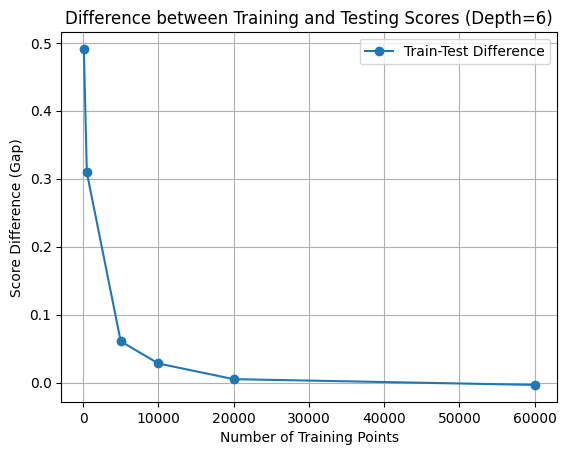

In [ ]:
#Siyoung Kim
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from torchvision import datasets, transforms

# Custom transform to convert tensor to numpy array and remove channel dimension
class ToNumpyNoChannel:
    def __call__(self, tensor):
        return tensor.squeeze(0).numpy()  # Remove channel dimension (C, H, W -> H, W)

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts PIL image to PyTorch tensor
    transforms.Normalize(mean=(0.5,), std=(0.5,)),  # Normalize to [-1, 1]
    ToNumpyNoChannel()  # Convert tensor to numpy array and remove channel dimension
])

# Load datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Access data and labels as NumPy arrays
X_train = np.array([train_dataset[i][0] for i in range(len(train_dataset))])  # Features
y_train = np.array([train_dataset[i][1] for i in range(len(train_dataset))])  # Labels
X_test = np.array([test_dataset[i][0] for i in range(len(test_dataset))])    # Features
y_test = np.array([test_dataset[i][1] for i in range(len(test_dataset))])    # Labels

#from (60000, 28, 28) to (60000, 784)
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

# Fixed parameters as per instructions
depth = 6
training_sizes = [100, 500, 5000, 10000, 20000, 60000]
train_scores = []
test_scores = []

for n in training_sizes:
    # Subset the training data
    X_subset = X_train[:n, :]
    y_subset = y_train[:n]

    # Define and train the model
    model = DecisionTreeClassifier(max_depth=depth, random_state=0)
    model.fit(X_subset, y_subset)

    # Record accuracies
    train_scores.append(model.score(X_subset, y_subset))
    test_scores.append(model.score(X_test, y_test))

# Calculate the difference
score_diff = [i - j for i, j in zip(train_scores, test_scores)]

# Plotting the trend
fig, ax = plt.subplots()
ax.plot(training_sizes, score_diff, marker='o', label='Train-Test Difference')
ax.set_xlabel('Number of Training Points')
ax.set_ylabel('Score Difference (Gap)')
ax.set_title('Difference between Training and Testing Scores (Depth=6)')
ax.grid(True)
ax.legend()
plt.show()

**Graph Analysis**

The plot clearly shows the relationship between the volume of training data and the model's ability to generalize.

At small Training Samples (e.g. N= 100,500), the gap between training and testing scores is at its peak. Even with a fixed depth of 6, the model has enough complexity to memoriz the specific noise of a small dataset
rather than learning its underlying patterns.

By fixing the depth at 6, we've limited the learning capacity of our model. Once we reach 60,000 points, the model has effectively reached its performance for this specific depth,and the training score becomes a more reliable predictor of the testing score .

The trend shows that increasing the amount of training data is one of the most effective strategies to decrease overfitting
ensuring that a model generalizes well to unseen data.

# Problem 5

We now turn to a somewhat more sophisticated data set: CIFAR10.

Load the data using:
```
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
```

Part 1. How many data points are there, and how many labels? How many points for each label?

Part 2. Figure out how to display some of the images from CIFAR10.

Part 3: Reshape X_train into a matrix X_tr so that each row is a data point.
 What are the dimensions of X_train?

Part 4: Generate decision trees of depth 1 to 15, and for each, compute the training accuracy and the testing accuracy.

If you did this correctly and ran the notebook, you noticed that CIFAR10 indeed looks like a ``harder'' problem. Deep trees are again doing very well on the training set, and they do a little better than guessing on the testing data, but not as well as they do on MNIST. We will revisit CIFAR10 several times, as we develop more powerful tools. And we will see that we will do much better than deep decision trees!

Note from lab: can use imshow(?) to visualize

In [ ]:
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [ ]:
#Part 1:
print("Training points:", X_train.shape[0])
print("Test points:", X_test.shape[0])
print("Total:", X_train.shape[0] + X_test.shape[0])
print("Number of labels:", len(labels))

unique, counts = np.unique(y_train, return_counts=True)
print("Training data points per label distribution:")
print(dict(zip([labels[i] for i in unique], counts)))

unique, counts = np.unique(y_test, return_counts=True)
print("Testing data points per label distribution:")
print(dict(zip([labels[i] for i in unique], counts)))

Training points: 50000
Test points: 10000
Total: 60000
Number of labels: 10
Training data points per label distribution:
{'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}
Testing data points per label distribution:
{'airplane': np.int64(1000), 'automobile': np.int64(1000), 'bird': np.int64(1000), 'cat': np.int64(1000), 'deer': np.int64(1000), 'dog': np.int64(1000), 'frog': np.int64(1000), 'horse': np.int64(1000), 'ship': np.int64(1000), 'truck': np.int64(1000)}


It is quite clear that the distribution is uniform, meaning that all of the labels have 5000 training data points (images) and 1000 testing data points (images). Given that there are 10 different labels, there are a total of 50000 training images and 10000 testing images, which amountsa to 60000 total images (data points).

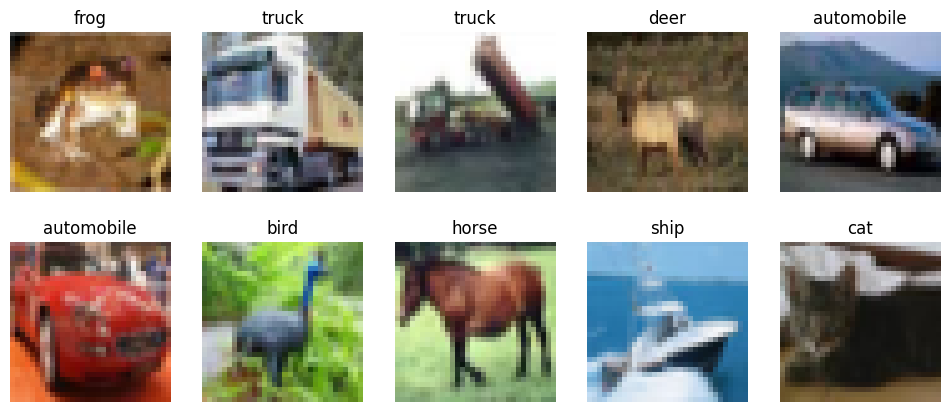

In [ ]:
#Part 2:
fig, axes = plt.subplots(2, 5, figsize=(12,5)) #plot 2 rows of 5 images:
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(labels[y_train[i][0]])
    ax.axis('off') #remove axes

In [ ]:
print("The original image dimensions are",X_train.shape[1], "x", X_train.shape[2],"with", X_train.shape[3], "color channels")

X_tr = X_train.reshape(X_train.shape[0], -1) #flatten images into vectors
X_te = X_test.reshape(X_test.shape[0], -1)

print("After reshaping:\nTraining data dimensions:", X_tr.shape,"\nTesting data dimensions:", X_te.shape)

The original image dimensions are 32 x 32 with 3 color channels
After reshaping:
Training data dimensions: (50000, 3072) 
Testing data dimensions: (10000, 3072)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

train_acc = []
test_acc = []

for d in range(1, 16):
    print("Training Decision Tree with max_depth =", d)

    clf = DecisionTreeClassifier(max_depth=d, random_state=0)
    clf.fit(X_tr, y_train.ravel())

    train_pred = clf.predict(X_tr)
    test_pred = clf.predict(X_te)

    tr_acc = accuracy_score(y_train, train_pred)
    te_acc = accuracy_score(y_test, test_pred)

    train_acc.append(tr_acc)
    test_acc.append(te_acc)

    print("  Training accuracy:", round(tr_acc, 4))
    print("  Testing accuracy: ", round(te_acc, 4))
    print("\n")


Training Decision Tree with max_depth = 1
  Training accuracy: 0.157
  Testing accuracy:  0.157


Training Decision Tree with max_depth = 2
  Training accuracy: 0.1927
  Testing accuracy:  0.1955


Training Decision Tree with max_depth = 3
  Training accuracy: 0.2376
  Testing accuracy:  0.2394


Training Decision Tree with max_depth = 4
  Training accuracy: 0.2571
  Testing accuracy:  0.2527


Training Decision Tree with max_depth = 5
  Training accuracy: 0.2676
  Testing accuracy:  0.2669


Training Decision Tree with max_depth = 6
  Training accuracy: 0.2959
  Testing accuracy:  0.2812


Training Decision Tree with max_depth = 7
  Training accuracy: 0.3223
  Testing accuracy:  0.2929


Training Decision Tree with max_depth = 8
  Training accuracy: 0.3496
  Testing accuracy:  0.3024


Training Decision Tree with max_depth = 9
  Training accuracy: 0.3828
  Testing accuracy:  0.3042


Training Decision Tree with max_depth = 10
  Training accuracy: 0.4263
  Testing accuracy:  0.3059


T

As the tree depth increases, training accuracy improves substantially, which makes sense given that deeper trees are capable of fitting the training data more closely. However, while test accuracy also increases initially with tree depth, it reaches a maximum at a depth of 10, with an accuracy around 30.59%, and then slightly decreases for deeper trees, showing clear overfitting.

# The next two problems are optional, but recommended

We will be generating lots of random data sets in this class, in order to test the behavior of machine learning algorithms.

So it's useful to know how to generate random data, and display it.

# Problem 6 (Optional, recommended)

**Part 1.** Generate 1,000 samples of 2 dimensional data from the Gaussian distribution $\left(\begin{array}{cc}X_{i}\\Y_{i}\end{array}\right)∼N\biggl(\left(\begin{array}{cc}-5\\5\end{array}\right),\left(\begin{array}{cc}2 & 0.8\\0.8 & 3\end{array}\right)\biggr)$.

**Part 2.** Plot these points.

**Part 3.** Find the Eigenvectors and Eigenvalues of the covariance matrix using np.linalg.eig, or np.linalg.eigh, or something else of your choice.

**Part 4.** Now take the 1,000 points you generated in the first part, and use them to estimate the mean and covariance matrix for this multi-dimensional data using elementary numpy commands, i.e., addition, multiplication, division (do not use a command that takes data and returns the mean or standard deviation).

*Remark*: If you did this correctly: You should have made a number of observations. (i) The points you plotted should look like an elongated ellipse. (ii) The axis of elongation (the major axis of the ellipse) should be aligned with the eigenvector you computed that has the largest eigenvalue. The minor axis, should be aligned with the other eigenvector you computed. (iii) In the last part, you computed what is called the *empirical covariance* matrix. This should be quite close to the covariance matrix you used to generate the data. If we used more and more points (10,000, 100,000, etc.), then our empirical estimate would look more and more like what we used to generate the data.


Eigenvalues:
 [1.55660189 3.44339811]
Eigenvectors:
 [[-0.87464248 -0.48476853]
 [ 0.48476853 -0.87464248]]

Empirical estimates
Estimated mean: [-5.04486084  4.9773957 ]
Estimated covariance matrix:
 [[2.01748239 0.70047135]
 [0.70047135 2.96865942]]


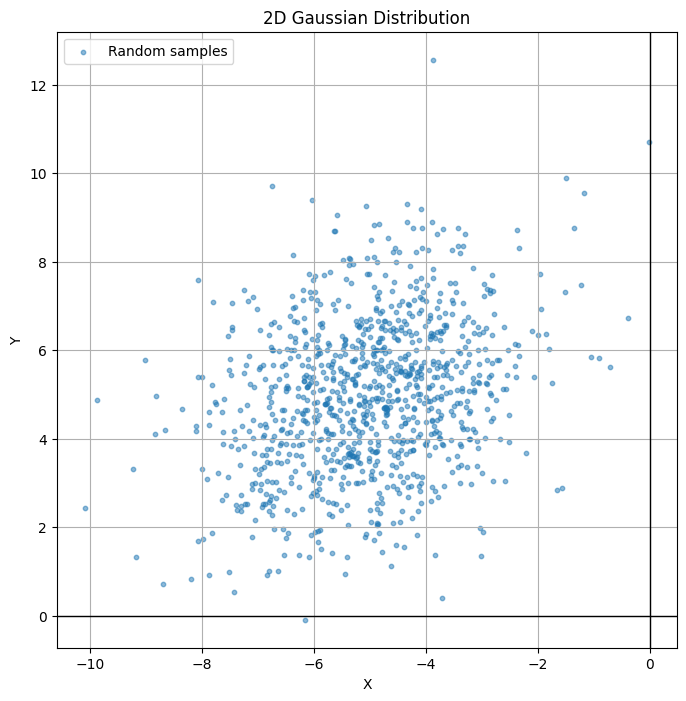

In [ ]:
#Siyoung Kim
import numpy as np
import matplotlib.pyplot as plt

# Part 1: Generate 1,000 samples
mean_true = np.array([-5, 5])
cov_true = np.array([[2, 0.8], [0.8, 3]])
n_samples = 1000
# Generating the data
data = np.random.multivariate_normal(mean_true, cov_true, n_samples)

# Part 2: Plot the generated points
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, s=10, label='Random samples')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("2D Gaussian Distribution")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()

# Part 3: Find eigenvalues/eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_true)
print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

# Part 4: Estimate mean
est_mean = np.sum(data, axis=0) / n_samples

#Estimate covariance
centered_data = data - est_mean
est_cov = (centered_data.T @ centered_data) / (n_samples - 1)

print("\nEmpirical estimates")
print("Estimated mean:", est_mean)
print("Estimated covariance matrix:\n", est_cov)

plt.show()

# Problem 7: Central Limit Theorem (Optional, recommended)

Back in EE351K you learned the Law of Large Numbers, and the Central Limit Theorem, among many other things. The Law of Large Numbers says that if $X_i$ are independent and identically distributed (iid) random variables, then $(1/N) \sum X_i$ converges to $\mathbb{E}[X]$. That's the law of large numbers.

You also learned the Central Limit Theorem. This says that if $X_i$ are zero mean, have variance 1, and are iid, then $(1/\sqrt{N}) \sum X_i$ converges to a random variable. Which random variable? A standard (zero mean, unit variance) Gaussian.

We're going to check the central limit theorem empirically, as an excuse to do more practice with Python and numpy and basic plotting.

Let $X_i$ be an iid Bernoulli random variable with value \{-1,1\}. Look at the random variable
$Z_n = \frac{1}{\sqrt{n}}\sum X_i$. By taking 1000 samples from $Z_n$, plot its histogram. **Note**: To generate 1,000 samples from $Z_n$, you need to generate $1,000 \times n$ samples of $X_i$, since each $Z$ needs $1,000$ $X_i$'s. Now check that for small $n$ (set $n= 5$) $Z_n$ does not look that much like a Gaussian, but when $n$ is bigger (set $n = 50$) it looks much more like a Gaussian. Check also for much bigger $n$: $n = 250$, to see that at this point, one can really see the bell curve.